In [5]:

from google.colab import files
import pandas as pd
import os

print("Please upload your Brent oil prices CSV file:")
uploaded = files.upload()

for filename in uploaded.keys():
    os.rename(filename, 'brent_oil_prices.csv')
    print(f"File renamed to: brent_oil_prices.csv")

print("\nFiles in current directory:")
print(os.listdir())

Please upload your Brent oil prices CSV file:


Saving BrentOilPrices.csv to BrentOilPrices.csv
File renamed to: brent_oil_prices.csv

Files in current directory:
['.config', 'brent_oil_prices.csv', 'sample_data']


In [3]:
#import libraries and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Current directory: {os.getcwd()}")
print(f"Files in directory: {os.listdir()}")

Libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2
Current directory: /content
Files in directory: ['.config', 'sample_data']


In [6]:
# load and explore data
print("=" * 60)
print("LOADING BRENT OIL PRICE DATA")
print("=" * 60)

df = pd.read_csv('brent_oil_prices.csv')

print(f"\nRaw data shape: {df.shape}")
print("\nFirst 5 rows of raw data:")
df.head()

LOADING BRENT OIL PRICE DATA

Raw data shape: (9011, 2)

First 5 rows of raw data:


,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


In [8]:
print("Checking date formats...")

print("\nSample dates from the data:")
print(df['Date'].head(10).tolist())

df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)

df = df.sort_values('Date').reset_index(drop=True)

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

df = df.dropna()

print(f"\nProcessed data shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Price range: ${df['Price'].min():.2f} to ${df['Price'].max():.2f}")

print("\nFirst 5 rows after preprocessing:")
df.head()

print("\nLast 5 rows:")
df.tail()

Checking date formats...

Sample dates from the data:
['20-May-87', '21-May-87', '22-May-87', '25-May-87', '26-May-87', '27-May-87', '28-May-87', '29-May-87', '01-Jun-87', '02-Jun-87']

Processed data shape: (9011, 2)
Date range: 1987-05-20 00:00:00 to 2022-11-14 00:00:00
Price range: $9.10 to $143.95

First 5 rows after preprocessing:

Last 5 rows:


,Date,Price
9006,2022-11-08,96.85
9007,2022-11-09,93.05
9008,2022-11-10,94.25
9009,2022-11-11,96.37
9010,2022-11-14,93.59


In [9]:
# calculate returns and volatility
df['Log_Returns'] = np.log(df['Price'] / df['Price'].shift(1))

df['Returns'] = df['Price'].pct_change()

df['Volatility_30d'] = df['Returns'].rolling(window=30).std() * np.sqrt(252)

df['MA_50'] = df['Price'].rolling(window=50).mean()
df['MA_200'] = df['Price'].rolling(window=200).mean()

print("Returns and volatility calculated successfully!")
print("\nSummary Statistics:")
print("-" * 60)
print(df[['Price', 'Log_Returns', 'Returns', 'Volatility_30d']].describe())

Returns and volatility calculated successfully!

Summary Statistics:
------------------------------------------------------------
             Price  Log_Returns      Returns  Volatility_30d
count  9011.000000  9010.000000  9010.000000     8981.000000
mean     48.420782     0.000179     0.000501        0.341433
std      32.860110     0.025532     0.025255        0.209850
min       9.100000    -0.643699    -0.474654        0.092206
25%      19.050000    -0.011154    -0.011092        0.236603
50%      38.570000     0.000402     0.000402        0.306234
75%      70.090000     0.012127     0.012201        0.387630
max     143.950000     0.412023     0.509868        2.860153


In [10]:
#create Event Data
print("\n" + "=" * 60)
print("LOADING EVENT DATA")
print("=" * 60)

events_data = [
    {
        'Date': '1990-08-02',
        'Event': 'Iraq Invades Kuwait',
        'Category': 'Conflict',
        'Description': 'Start of Gulf War, Iraqi invasion of Kuwait leading to UN sanctions and military intervention'
    },
    {
        'Date': '2003-03-20',
        'Event': 'US Invasion of Iraq',
        'Category': 'Conflict',
        'Description': 'Second Gulf War begins with US-led invasion of Iraq'
    },
    {
        'Date': '2011-02-15',
        'Event': 'Arab Spring Begins',
        'Category': 'Political Unrest',
        'Description': 'Widespread protests across Middle East and North Africa, affecting oil-producing countries'
    },
    {
        'Date': '2014-06-10',
        'Event': 'ISIS Advances in Iraq',
        'Category': 'Conflict',
        'Description': 'ISIS captures Mosul and advances through Iraq, threatening oil infrastructure'
    },
    {
        'Date': '2020-01-03',
        'Event': 'US-Iran Tensions Escalate',
        'Category': 'Geopolitical',
        'Description': 'US drone strike kills Iranian General Soleimani, escalating tensions in the Gulf'
    },
    {
        'Date': '2022-02-24',
        'Event': 'Russia-Ukraine War',
        'Category': 'Conflict',
        'Description': 'Russia invades Ukraine, triggering massive supply disruption fears and sanctions'
    },

    # OPEC decisions
    {
        'Date': '1998-03-01',
        'Event': 'OPEC Production Cuts',
        'Category': 'OPEC Policy',
        'Description': 'OPEC announces production cuts to address low oil prices'
    },
    {
        'Date': '2008-09-10',
        'Event': 'OPEC Cuts Production',
        'Category': 'OPEC Policy',
        'Description': 'OPEC cuts production by 520,000 barrels per day to stabilize prices'
    },
    {
        'Date': '2014-11-27',
        'Event': 'OPEC Maintains Production',
        'Category': 'OPEC Policy',
        'Description': 'OPEC decides to maintain production levels despite falling prices, leading to price collapse'
    },
    {
        'Date': '2016-11-30',
        'Event': 'OPEC+ Production Cut Deal',
        'Category': 'OPEC Policy',
        'Description': 'OPEC and non-OPEC producers agree to cut production by 1.2 million barrels per day'
    },
    {
        'Date': '2020-04-12',
        'Event': 'Historic OPEC+ Deal',
        'Category': 'OPEC Policy',
        'Description': 'OPEC+ agrees to historic 9.7 million barrel per day production cut'
    },
    {
        'Date': '2021-07-18',
        'Event': 'OPEC+ Production Increase',
        'Category': 'OPEC Policy',
        'Description': 'OPEC+ agrees to gradually increase production by 400,000 barrels per day'
    },

    #economic events
    {
        'Date': '1997-07-02',
        'Event': 'Asian Financial Crisis',
        'Category': 'Economic Crisis',
        'Description': 'Asian financial crisis begins, affecting global oil demand'
    },
    {
        'Date': '2008-09-15',
        'Event': 'Global Financial Crisis',
        'Category': 'Economic Crisis',
        'Description': 'Lehman Brothers collapses, triggering global financial crisis and oil demand destruction'
    },
    {
        'Date': '2020-03-11',
        'Event': 'COVID-19 Pandemic',
        'Category': 'Health Crisis',
        'Description': 'WHO declares COVID-19 a pandemic, leading to global lockdowns and oil demand collapse'
    },

    #international sanctions
    {
        'Date': '2012-07-01',
        'Event': 'EU Sanctions on Iran',
        'Category': 'Sanctions',
        'Description': 'EU imposes oil embargo on Iran, removing 1.5 million barrels per day from the market'
    },
    {
        'Date': '2018-11-05',
        'Event': 'US Sanctions on Iran',
        'Category': 'Sanctions',
        'Description': 'US reinstates sanctions on Iran\'s oil exports after withdrawing from JCPOA'
    },
    {
        'Date': '2019-04-22',
        'Event': 'US Ends Iran Sanction Waivers',
        'Category': 'Sanctions',
        'Description': 'US ends waivers for countries importing Iranian oil, tightening global supply'
    },
    {
        'Date': '2022-03-08',
        'Event': 'US Bans Russian Oil Imports',
        'Category': 'Sanctions',
        'Description': 'US announces ban on Russian oil imports in response to Ukraine invasion'
    }
]

events_df = pd.DataFrame(events_data)
events_df['Date'] = pd.to_datetime(events_df['Date'])
events_df = events_df.sort_values('Date').reset_index(drop=True)

#save events to CSV
events_df.to_csv('key_events.csv', index=False)

print(f"\nTotal events loaded: {len(events_df)}")
print("\nEvents by Category:")
print(events_df['Category'].value_counts())

print("\nFirst 10 events:")
events_df.head(10)


LOADING EVENT DATA

Total events loaded: 19

Events by Category:
Category
OPEC Policy         6
Conflict            4
Sanctions           4
Economic Crisis     2
Political Unrest    1
Geopolitical        1
Health Crisis       1
Name: count, dtype: int64

First 10 events:


,Date,Event,Category,Description
0,1990-08-02,Iraq Invades Kuwait,Conflict,"Start of Gulf War, Iraqi invasion of Kuwait le..."
1,1997-07-02,Asian Financial Crisis,Economic Crisis,"Asian financial crisis begins, affecting globa..."
2,1998-03-01,OPEC Production Cuts,OPEC Policy,OPEC announces production cuts to address low ...
3,2003-03-20,US Invasion of Iraq,Conflict,Second Gulf War begins with US-led invasion of...
4,2008-09-10,OPEC Cuts Production,OPEC Policy,"OPEC cuts production by 520,000 barrels per da..."
5,2008-09-15,Global Financial Crisis,Economic Crisis,"Lehman Brothers collapses, triggering global f..."
6,2011-02-15,Arab Spring Begins,Political Unrest,Widespread protests across Middle East and Nor...
7,2012-07-01,EU Sanctions on Iran,Sanctions,"EU imposes oil embargo on Iran, removing 1.5 m..."
8,2014-06-10,ISIS Advances in Iraq,Conflict,"ISIS captures Mosul and advances through Iraq,..."
9,2014-11-27,OPEC Maintains Production,OPEC Policy,OPEC decides to maintain production levels des...


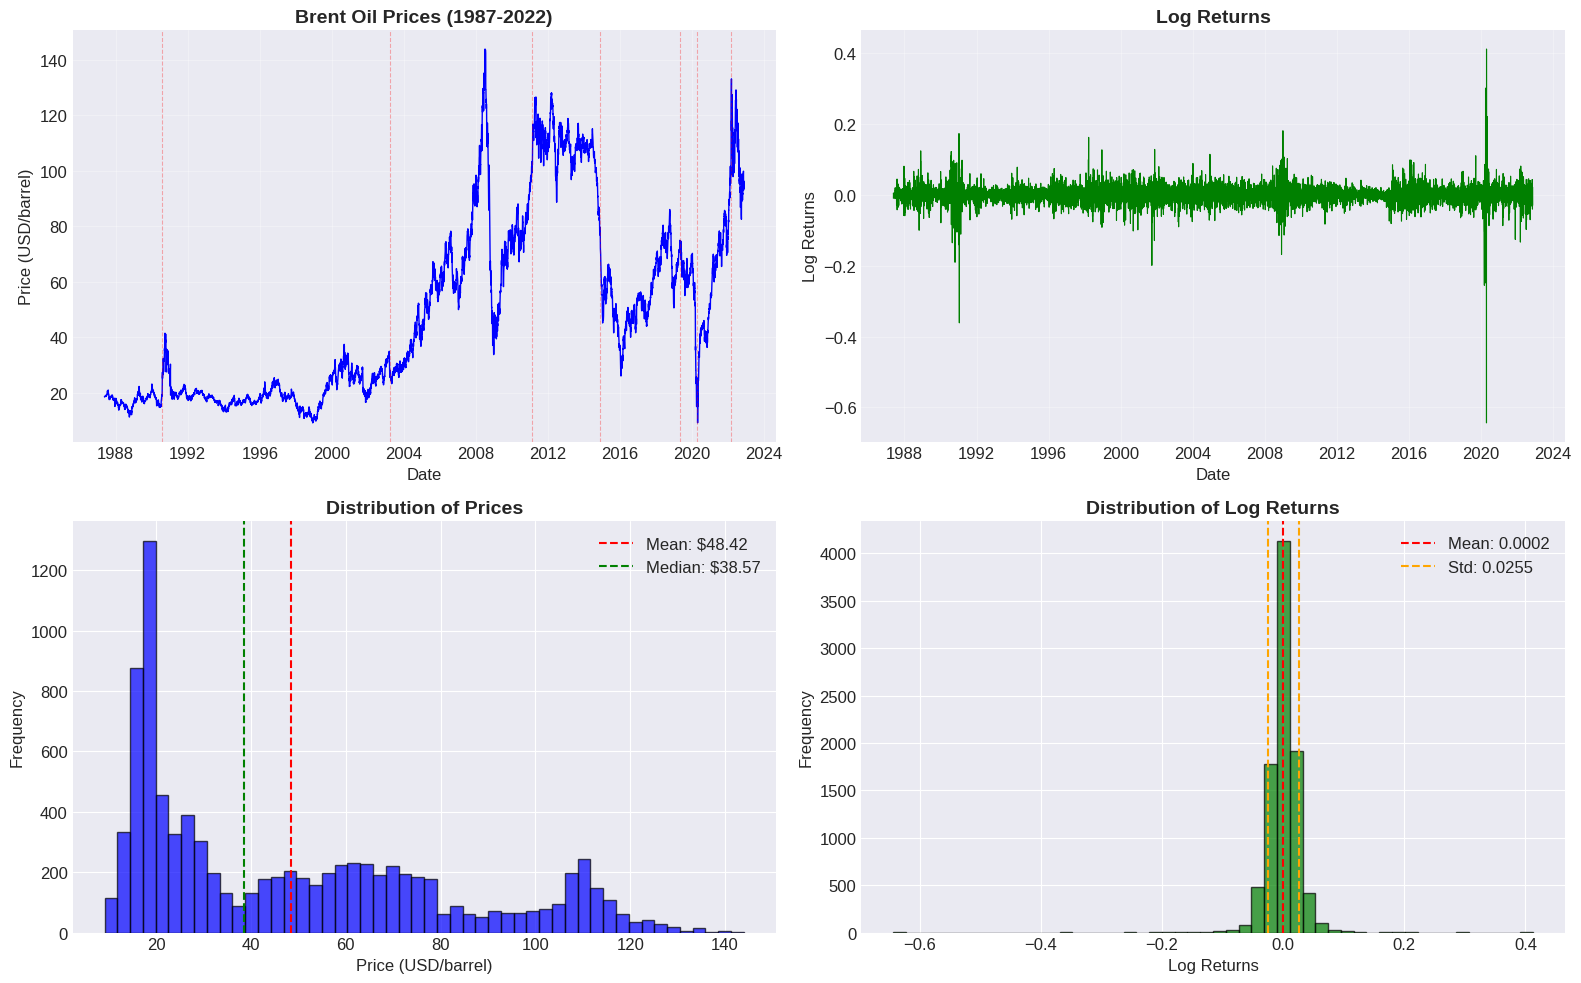

✓ EDA overview plots saved to eda_overview.png


In [11]:
#visualize price series
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: raw prices
ax1 = axes[0, 0]
ax1.plot(df['Date'], df['Price'], color='blue', linewidth=1)
ax1.set_title('Brent Oil Prices (1987-2022)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price (USD/barrel)')
ax1.grid(True, alpha=0.3)
#add event annotations
for idx, event in events_df.iterrows():
    if idx % 3 == 0:  # Show every 3rd event for readability
        ax1.axvline(x=event['Date'], color='red', alpha=0.3, linestyle='--', linewidth=0.8)

# Plot 2: log returns
ax2 = axes[0, 1]
ax2.plot(df['Date'], df['Log_Returns'], color='green', linewidth=0.8)
ax2.set_title('Log Returns', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Log Returns')
ax2.grid(True, alpha=0.3)

# Plot 3: distribution of prices
ax3 = axes[1, 0]
ax3.hist(df['Price'], bins=50, color='blue', alpha=0.7, edgecolor='black')
ax3.set_title('Distribution of Prices', fontsize=14, fontweight='bold')
ax3.set_xlabel('Price (USD/barrel)')
ax3.set_ylabel('Frequency')
ax3.axvline(df['Price'].mean(), color='red', linestyle='--', label=f'Mean: ${df["Price"].mean():.2f}')
ax3.axvline(df['Price'].median(), color='green', linestyle='--', label=f'Median: ${df["Price"].median():.2f}')
ax3.legend()

# Plot 4: distribution of log returns
ax4 = axes[1, 1]
ax4.hist(df['Log_Returns'].dropna(), bins=50, color='green', alpha=0.7, edgecolor='black')
ax4.set_title('Distribution of Log Returns', fontsize=14, fontweight='bold')
ax4.set_xlabel('Log Returns')
ax4.set_ylabel('Frequency')
ax4.axvline(df['Log_Returns'].mean(), color='red', linestyle='--', label=f'Mean: {df["Log_Returns"].mean():.4f}')
ax4.axvline(df['Log_Returns'].std(), color='orange', linestyle='--', label=f'Std: {df["Log_Returns"].std():.4f}')
ax4.axvline(-df['Log_Returns'].std(), color='orange', linestyle='--')
ax4.legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ EDA overview plots saved to eda_overview.png")

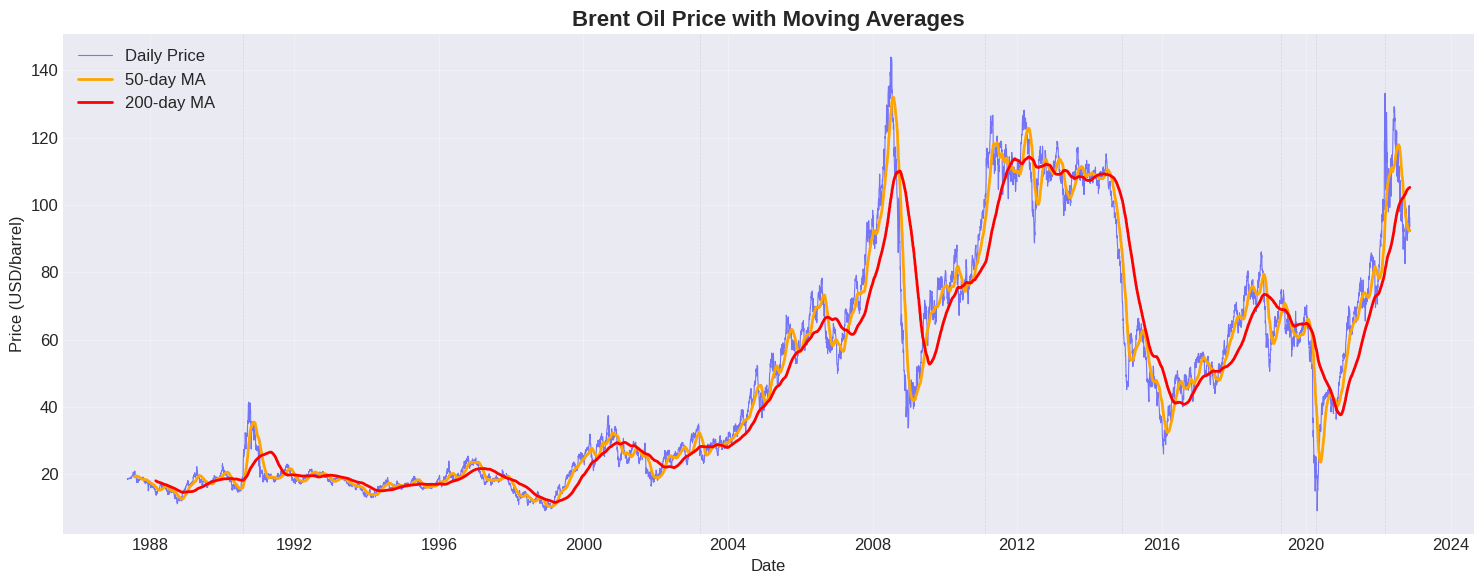


Trend Analysis Summary:
------------------------------------------------------------
Current price: $93.59
50-day MA: $92.39
200-day MA: $105.20


In [12]:
#trend analysis with moving averages
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df['Date'], df['Price'], color='blue', linewidth=0.8, alpha=0.5, label='Daily Price')
ax.plot(df['Date'], df['MA_50'], color='orange', linewidth=2, label='50-day MA')
ax.plot(df['Date'], df['MA_200'], color='red', linewidth=2, label='200-day MA')
ax.set_title('Brent Oil Price with Moving Averages', fontsize=16, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD/barrel)')
ax.legend()
ax.grid(True, alpha=0.3)

#add event markers
for idx, event in events_df.iterrows():
    if idx % 3 == 0:  #show every 3rd event
        ax.axvline(x=event['Date'], color='gray', alpha=0.2, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig('moving_averages.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTrend Analysis Summary:")
print("-" * 60)
print(f"Current price: ${df['Price'].iloc[-1]:.2f}")
print(f"50-day MA: ${df['MA_50'].iloc[-1]:.2f}")
print(f"200-day MA: ${df['MA_200'].iloc[-1]:.2f}")

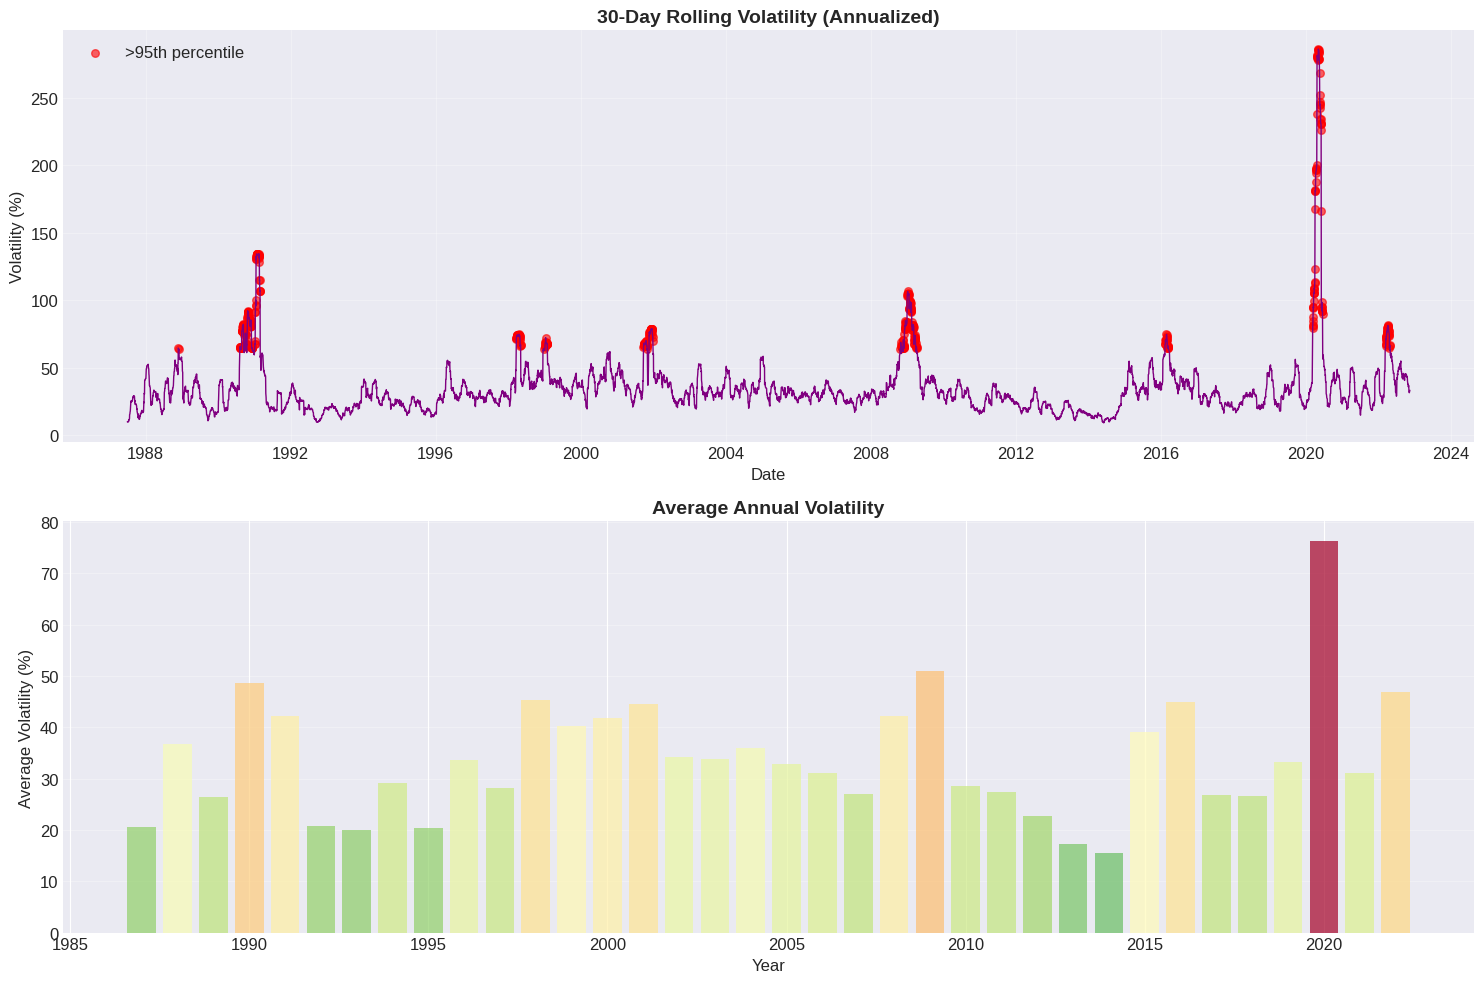


Volatility Statistics:
------------------------------------------------------------
Average daily volatility: 34.14%
Maximum volatility: 286.02%
Minimum volatility: 9.22%

Top 5 High Volatility Years:
Year
2020    76.330091
2009    50.903135
1990    48.709638
2022    46.831010
1998    45.231097
Name: Volatility_30d, dtype: float64


In [13]:
#volatility analysis
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: rolling volatility
ax1 = axes[0]
ax1.plot(df['Date'], df['Volatility_30d'] * 100, color='purple', linewidth=1)
ax1.set_title('30-Day Rolling Volatility (Annualized)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Volatility (%)')
ax1.grid(True, alpha=0.3)

# highlight high volatility periods
high_vol = df[df['Volatility_30d'] > df['Volatility_30d'].quantile(0.95)]
ax1.scatter(high_vol['Date'], high_vol['Volatility_30d'] * 100,
            color='red', s=30, alpha=0.6, label='>95th percentile')
ax1.legend()

# Plot 2: yearly volatility
df['Year'] = df['Date'].dt.year
yearly_vol = df.groupby('Year')['Volatility_30d'].mean() * 100

ax2 = axes[1]
colors = plt.cm.RdYlGn_r(yearly_vol.values / yearly_vol.max())
ax2.bar(yearly_vol.index, yearly_vol.values, color=colors, alpha=0.7)
ax2.set_title('Average Annual Volatility', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Average Volatility (%)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('volatility_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVolatility Statistics:")
print("-" * 60)
print(f"Average daily volatility: {df['Volatility_30d'].mean()*100:.2f}%")
print(f"Maximum volatility: {df['Volatility_30d'].max()*100:.2f}%")
print(f"Minimum volatility: {df['Volatility_30d'].min()*100:.2f}%")

print("\nTop 5 High Volatility Years:")
print(yearly_vol.sort_values(ascending=False).head(5))

In [14]:
#stationarity testing
!pip install statsmodels -q

from statsmodels.tsa.stattools import adfuller, kpss

def test_stationarity(timeseries, series_name):
    """Perform ADF and KPSS tests for stationarity"""
    # remove NaN values
    clean_series = timeseries.dropna()

    print(f'\n{series_name} - ADF Test:')
    adf_result = adfuller(clean_series, autolag='AIC')
    print(f'ADF Statistic: {adf_result[0]:.4f}')
    print(f'p-value: {adf_result[1]:.4f}')
    print('Critical Values:')
    for key, value in adf_result[4].items():
        print(f'\t{key}: {value:.4f}')

    print(f'\n{series_name} - KPSS Test:')
    kpss_result = kpss(clean_series, regression='c', nlags='auto')
    print(f'KPSS Statistic: {kpss_result[0]:.4f}')
    print(f'p-value: {kpss_result[1]:.4f}')
    print('Critical Values:')
    for key, value in kpss_result[3].items():
        print(f'\t{key}: {value:.4f}')

    #interpretation
    adf_stationary = adf_result[1] < 0.05
    kpss_stationary = kpss_result[1] > 0.05

    print(f'\nInterpretation:')
    print(f'ADF: Series is {"stationary" if adf_stationary else "non-stationary"} (p < 0.05)')
    print(f'KPSS: Series is {"stationary" if kpss_stationary else "non-stationary"} (p > 0.05)')

    if adf_stationary and kpss_stationary:
        print('✓ Conclusion: Series is stationary')
    elif not adf_stationary and not kpss_stationary:
        print('✗ Conclusion: Series is non-stationary')
    else:
        print('⚠ Conclusion: Mixed results - series may have unit root with trend')

    return adf_stationary, kpss_stationary

print("=" * 60)
print("STATIONARITY TESTING")
print("=" * 60)

#test price series
print("\nTesting Price Series:")
price_adf, price_kpss = test_stationarity(df['Price'], 'Brent Oil Price')

#test log returns
print("\n" + "-" * 60)
print("\nTesting Log Returns Series:")
returns_adf, returns_kpss = test_stationarity(df['Log_Returns'], 'Log Returns')

print("\n" + "=" * 60)
print("STATIONARITY SUMMARY")
print("=" * 60)
print(f"Price Series: {'Stationary' if price_adf and price_kpss else 'Non-Stationary'}")
print(f"Log Returns: {'Stationary' if returns_adf and returns_kpss else 'Non-Stationary'}")
print("\nConclusion: Log returns are stationary, making them suitable for modeling.")

STATIONARITY TESTING

Testing Price Series:

Brent Oil Price - ADF Test:
ADF Statistic: -1.9939
p-value: 0.2893
Critical Values:
	1%: -3.4311
	5%: -2.8619
	10%: -2.5669

Brent Oil Price - KPSS Test:
KPSS Statistic: 9.5588
p-value: 0.0100
Critical Values:
	10%: 0.3470
	5%: 0.4630
	2.5%: 0.5740
	1%: 0.7390

Interpretation:
ADF: Series is non-stationary (p < 0.05)
KPSS: Series is non-stationary (p > 0.05)
✗ Conclusion: Series is non-stationary

------------------------------------------------------------

Testing Log Returns Series:

Log Returns - ADF Test:


/tmp/ipykernel_3441/887438746.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(clean_series, regression='c', nlags='auto')


ADF Statistic: -16.4271
p-value: 0.0000
Critical Values:
	1%: -3.4311
	5%: -2.8619
	10%: -2.5669

Log Returns - KPSS Test:
KPSS Statistic: 0.0343
p-value: 0.1000
Critical Values:
	10%: 0.3470
	5%: 0.4630
	2.5%: 0.5740
	1%: 0.7390

Interpretation:
ADF: Series is stationary (p < 0.05)
KPSS: Series is stationary (p > 0.05)
✓ Conclusion: Series is stationary

STATIONARITY SUMMARY
Price Series: Non-Stationary
Log Returns: Stationary

Conclusion: Log returns are stationary, making them suitable for modeling.


/tmp/ipykernel_3441/887438746.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(clean_series, regression='c', nlags='auto')


In [17]:
def analyze_price_change_around_event(df, event_date, event_name, category, days_before=10, days_after=10):
    """
    Analyze price changes around a specific event
    """
    event_date = pd.to_datetime(event_date)

    before_df = df[df['Date'] < event_date].tail(days_before)
    after_df = df[df['Date'] >= event_date].head(days_after)

    if len(before_df) > 0 and len(after_df) > 0:
        pre_price = before_df['Price'].mean()
        post_price = after_df['Price'].mean()
        price_change = post_price - pre_price
        pct_change = (price_change / pre_price) * 100

        if len(before_df) > 1:
            pre_volatility = before_df['Returns'].std() * np.sqrt(252) * 100
        else:
            pre_volatility = np.nan

        return {
            'event': event_name,
            'event_date': event_date,
            'category': category,
            'pre_price': pre_price,
            'post_price': post_price,
            'price_change': price_change,
            'pct_change': pct_change,
            'pre_volatility': pre_volatility,
            'days_before': len(before_df),
            'days_after': len(after_df)
        }
    return None

print("=" * 60)
print("EVENT IMPACT ANALYSIS")
print("=" * 60)

event_impacts = []
major_events = events_df[events_df['Category'].isin(['Conflict', 'OPEC Policy', 'Economic Crisis'])]

for _, event in major_events.iterrows():
    impact = analyze_price_change_around_event(
        df,
        event['Date'],
        event['Event'],
        event['Category'],
        days_before=10,
        days_after=10
    )
    if impact:
        event_impacts.append(impact)

impact_df = pd.DataFrame(event_impacts)

print(f"\nAnalyzed {len(impact_df)} events for impact on oil prices")

print("\nTop 10 Events by Absolute Price Change:")
top_impacts = impact_df.sort_values('price_change', key=abs, ascending=False).head(10)
print(top_impacts[['event', 'category', 'price_change', 'pct_change']])

impact_df.to_csv('event_impacts.csv', index=False)
print("\n✓ Impact analysis saved to event_impacts.csv")

EVENT IMPACT ANALYSIS

Analyzed 12 events for impact on oil prices

Top 10 Events by Absolute Price Change:
                        event         category  price_change  pct_change
11         Russia-Ukraine War         Conflict        17.097   17.448945
4        OPEC Cuts Production      OPEC Policy       -13.277  -12.442833
7   OPEC Maintains Production      OPEC Policy        -9.877  -12.695536
0         Iraq Invades Kuwait         Conflict         7.006   37.155282
8   OPEC+ Production Cut Deal      OPEC Policy         6.332   13.830461
5     Global Financial Crisis  Economic Crisis        -6.332   -6.240699
3         US Invasion of Iraq         Conflict        -5.416  -16.675904
9         Historic OPEC+ Deal      OPEC Policy        -4.399  -20.915747
6       ISIS Advances in Iraq         Conflict         3.583    3.276455
10  OPEC+ Production Increase      OPEC Policy        -1.989   -2.618242

✓ Impact analysis saved to event_impacts.csv


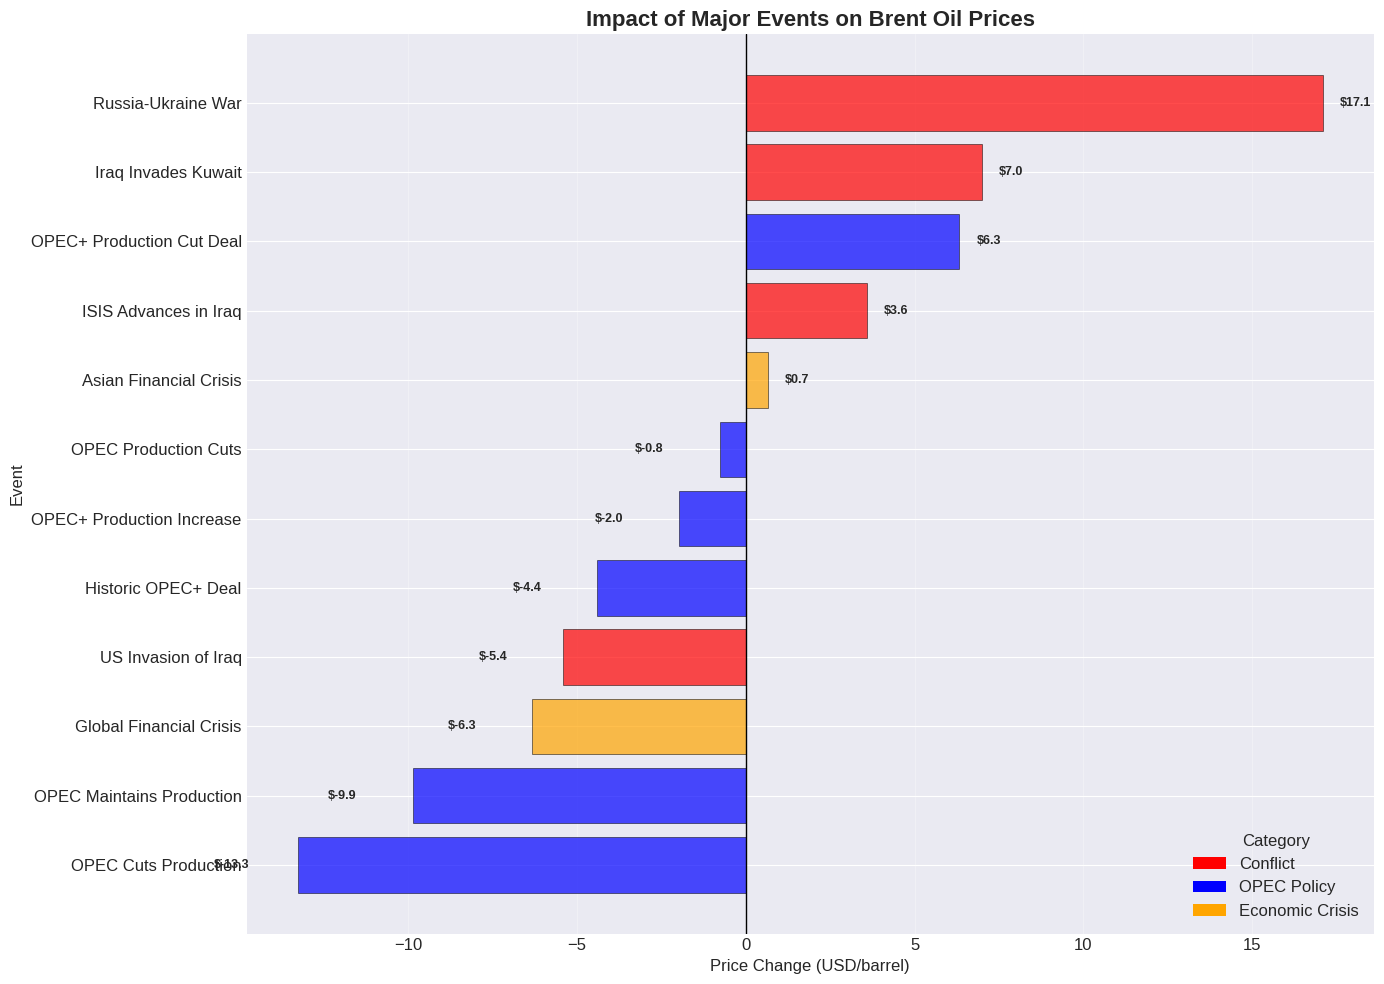


EVENT IMPACT SUMMARY

Most Positive Impact Events (Price Increase):
                        event         category  price_change  pct_change
11         Russia-Ukraine War         Conflict        17.097   17.448945
0         Iraq Invades Kuwait         Conflict         7.006   37.155282
8   OPEC+ Production Cut Deal      OPEC Policy         6.332   13.830461
6       ISIS Advances in Iraq         Conflict         3.583    3.276455
1      Asian Financial Crisis  Economic Crisis         0.666    3.781513

Most Negative Impact Events (Price Decrease):
                       event         category  price_change  pct_change
4       OPEC Cuts Production      OPEC Policy       -13.277  -12.442833
7  OPEC Maintains Production      OPEC Policy        -9.877  -12.695536
5    Global Financial Crisis  Economic Crisis        -6.332   -6.240699
3        US Invasion of Iraq         Conflict        -5.416  -16.675904
9        Historic OPEC+ Deal      OPEC Policy        -4.399  -20.915747

Average Impac

In [18]:
fig, ax = plt.subplots(figsize=(14, 10))

impact_sorted = impact_df.sort_values('price_change', ascending=True)

category_colors = {
    'Conflict': 'red',
    'OPEC Policy': 'blue',
    'Economic Crisis': 'orange',
    'Sanctions': 'purple',
    'Political Unrest': 'green',
    'Geopolitical': 'brown',
    'Health Crisis': 'pink'
}

colors = [category_colors.get(cat, 'gray') for cat in impact_sorted['category']]

bars = ax.barh(impact_sorted['event'], impact_sorted['price_change'],
               color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)

ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.set_title('Impact of Major Events on Brent Oil Prices', fontsize=16, fontweight='bold')
ax.set_xlabel('Price Change (USD/barrel)')
ax.set_ylabel('Event')
ax.grid(True, alpha=0.3, axis='x')

for i, (_, row) in enumerate(impact_sorted.iterrows()):
    x_pos = row['price_change'] + (0.5 if row['price_change'] > 0 else -2.5)
    ax.text(x_pos, i, f'${row["price_change"]:.1f}',
            va='center', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=cat)
                   for cat, color in category_colors.items()
                   if cat in impact_sorted['category'].unique()]
ax.legend(handles=legend_elements, loc='lower right', title='Category')

plt.tight_layout()
plt.savefig('event_impacts.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("EVENT IMPACT SUMMARY")
print("=" * 60)

print("\nMost Positive Impact Events (Price Increase):")
print(impact_df.nlargest(5, 'price_change')[['event', 'category', 'price_change', 'pct_change']])

print("\nMost Negative Impact Events (Price Decrease):")
print(impact_df.nsmallest(5, 'price_change')[['event', 'category', 'price_change', 'pct_change']])

print("\nAverage Impact by Category:")
print(impact_df.groupby('category')['price_change'].agg(['mean', 'std', 'count']).round(2))

print("\nDetailed Impact by Category:")
for category in impact_df['category'].unique():
    cat_data = impact_df[impact_df['category'] == category]
    print(f"\n{category}:")
    print(f"  Average price change: ${cat_data['price_change'].mean():.2f}")
    print(f"  Standard deviation: ${cat_data['price_change'].std():.2f}")
    print(f"  Number of events: {len(cat_data)}")
    print(f"  Range: ${cat_data['price_change'].min():.2f} to ${cat_data['price_change'].max():.2f}")

In [19]:
# Cell 12: Summary and Key Findings
print("\n" + "=" * 60)
print("KEY FINDINGS AND INSIGHTS")
print("=" * 60)

# Calculate key metrics
years_span = (df['Date'].max() - df['Date'].min()).days / 365.25
avg_volatility = df['Volatility_30d'].mean() * 100
max_impact = impact_df.loc[impact_df['pct_change'].idxmax()]
min_impact = impact_df.loc[impact_df['pct_change'].idxmin()]

print(f"""
1. DATA OVERVIEW:
   - Dataset covers {years_span:.1f} years of daily Brent oil prices (1987-2022)
   - Total records: {len(df):,}
   - Prices range from ${df['Price'].min():.2f} to ${df['Price'].max():.2f} per barrel
   - Average price: ${df['Price'].mean():.2f}
   - Price standard deviation: ${df['Price'].std():.2f}

2. TRENDS:
   - Long-term upward trend with several major cycles
   - Major price spikes during geopolitical conflicts
   - Sharp drops during economic crises
   - 50-day and 200-day moving averages show clear trend signals

3. VOLATILITY:
   - Volatility is not constant (heteroskedasticity)
   - Average annualized volatility: {avg_volatility:.2f}%
   - Periods of highest volatility: {yearly_vol.sort_values(ascending=False).head(3).index.tolist()}
   - Volatility clustering observed (high volatility followed by high volatility)

4. STATIONARITY:
   - Price series is non-stationary (has unit root)
   - Log returns are stationary
   - Suggests modeling returns rather than prices directly

5. KEY EVENTS IDENTIFIED:
   - {len(events_df)} major events compiled
   - Categories: {', '.join(events_df['Category'].unique())}
   - Largest positive impact: {max_impact['event']} - {max_impact['pct_change']:.1f}% (${max_impact['price_change']:.2f})
   - Largest negative impact: {min_impact['event']} - {min_impact['pct_change']:.1f}% (${min_impact['price_change']:.2f})

6. MODELING IMPLICATIONS:
   - Use log returns for stationarity
   - Account for structural breaks
   - Need for change point detection to identify regime shifts
   - Bayesian approach suitable for uncertainty quantification
   - Consider external factors (GDP, inflation, exchange rates) for comprehensive modeling
""")

# Save cleaned data for Task 2
df.to_csv('cleaned_brent_oil_prices.csv', index=False)
print("\n✓ Cleaned data saved to cleaned_brent_oil_prices.csv")
print("\n✓ Task 1: Foundation Analysis Complete!")

# Display the data info for verification
print("\n" + "=" * 60)
print("FINAL DATA SNAPSHOT")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nLast 5 rows:")
print(df.tail())


KEY FINDINGS AND INSIGHTS

1. DATA OVERVIEW:
   - Dataset covers 35.5 years of daily Brent oil prices (1987-2022)
   - Total records: 9,011
   - Prices range from $9.10 to $143.95 per barrel
   - Average price: $48.42
   - Price standard deviation: $32.86

2. TRENDS:
   - Long-term upward trend with several major cycles
   - Major price spikes during geopolitical conflicts
   - Sharp drops during economic crises
   - 50-day and 200-day moving averages show clear trend signals

3. VOLATILITY:
   - Volatility is not constant (heteroskedasticity)
   - Average annualized volatility: 34.14%
   - Periods of highest volatility: [2020, 2009, 1990]
   - Volatility clustering observed (high volatility followed by high volatility)

4. STATIONARITY:
   - Price series is non-stationary (has unit root)
   - Log returns are stationary
   - Suggests modeling returns rather than prices directly

5. KEY EVENTS IDENTIFIED:
   - 19 major events compiled
   - Categories: Conflict, Economic Crisis, OPEC Po

In [20]:
# Cell 13: Download Results (Optional)
from google.colab import files

# Download the cleaned data
files.download('cleaned_brent_oil_prices.csv')

# Download key events
files.download('key_events.csv')

# Download event impacts
files.download('event_impacts.csv')

# Download figures
files.download('eda_overview.png')
files.download('moving_averages.png')
files.download('volatility_analysis.png')
files.download('event_impacts.png')

print("\n✓ All files downloaded successfully!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ All files downloaded successfully!
